In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from dataset import CustomDataset
from models import Model
from utils import generate, f, initialize_parameters

import matplotlib.pyplot as plt
from functools import partial

In [8]:
# simulation parameters
J = 1
h = 100
image_size = 32
channels = 1

# Training parameters
num_samples = 10_000
batch_size = 1024
learning_rate = 0.001
num_epochs = 5
hidden_dim = 2
save_path = "saved_models"

In [9]:
# Create dataset and dataloader
dataset = CustomDataset(num_samples, image_size, channels=channels, J=J, h=h)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create model, loss function, and optimizer
model = Model(in_channels=channels, hidden_dim=hidden_dim)
model = initialize_parameters(model)

# try: model.load_state_dict(torch.load(f"{save_path}/{model.__class__.__name__}_C{channels}_J{J}_H{hidden_dim}.pth")["model_state_dict"])
# except FileNotFoundError: print("No saved models found, using random initialization")

print("number of trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("number of parameters:", sum(p.numel() for p in model.parameters()))

number of trainable parameters: 9
number of parameters: 29


In [10]:
# for p in model.parameters():
for name, p in model.named_parameters():
    print(f"{name:<32} {p.numel()}\t{p.requires_grad}")

conv.conv.weight                 18	False
conv.conv.bias                   2	False
conv.poly.conv_layers.0.weight   2	True
conv.poly.conv_layers.0.bias     1	True
conv.poly.conv_layers.1.weight   2	True
conv.poly.conv_layers.1.bias     1	True
lin1.weight                      1	True
lin1.bias                        1	True
lin2.weight                      1	True


In [11]:
criterion = nn.MSELoss()
# criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.5)
losses = []

In [12]:
# Training loop
# for epoch in range(20):
for epoch in range(num_epochs):
    for inputs, targets, T in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs, T)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.10f}')

Epoch [1/5], Loss: 0.4950527549
Epoch [2/5], Loss: 0.4790243506
Epoch [3/5], Loss: 0.4945951700
Epoch [4/5], Loss: 0.5040491819
Epoch [5/5], Loss: 0.5061521530


In [ ]:
# torch.save(
#     {
#         "model_state_dict": model.state_dict(),
#         "J": J,
#         "channels": channels,
#         "hidden_dim": hidden_dim,
#         "loss": loss.item(),
#     },
#     f'{save_path}/{model.__class__.__name__}_C{channels}_J{J}_H{hidden_dim}.pth'
# )

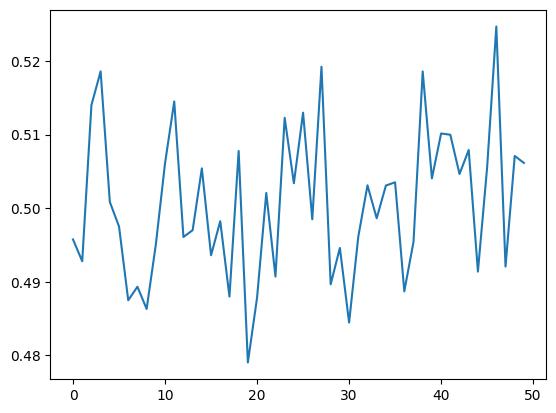

In [13]:
plt.plot(losses)

In [ ]:
T = torch.tensor([2.0]*1)
img = generate(partial(f, J=J, h=1), 128, T, n=100, p=(1.0, 0.01), in_channels=channels)

In [ ]:
plt.imshow(img[0, 0])

In [ ]:
T = torch.tensor([2.0]*2)
img = generate(model, 3, T, n=100, p=(1.0, 0.01), in_channels=channels)

In [ ]:
plt.imshow(img[1, 0]), 

In [ ]:
model(
    torch.tensor([
        [[
            [1, 1, 1],
            [1, -1, 1],
            [1, 1, 1]
        ]],
    ]).float(), torch.tensor([2.0]), True
)

In [ ]:
print(model.lin1.weight.data, model.lin1.bias.data)
print(model.lin2.weight.data, model.lin2.bias.data)